In [397]:
import pandas as pd
import prince  # For PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [608]:
# Load your data
data = pd.read_csv('merged_df.csv')

In [657]:
house_df = data[data['Category'] == 'house']
condo_df = data[data['Category'] == 'condo']
apt_df = data[data['Category'] == 'apartment']
com_df = data[data['Category'] == 'commercial']
land_df = data[data['Category'] == 'land']

In [659]:
# Standardize the data
scaler = StandardScaler()

In [661]:
def perform_pca(X, n_components=4):
    """
    Perform PCA using the 'prince' library.
    
    Parameters:
    - X (pd.DataFrame): Input dataset (independent variables only)
    - n_components (int): Number of principal components to retain

    Returns:
    - X_pca (pd.DataFrame): Transformed dataset with PCA components
    - loading_scores (pd.DataFrame): Loading scores (feature contributions)
    - explained_variance (pd.Series): Explained variance ratio
    """
    # Standardize the Data
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
    
    # PCA Transformation
    pca_model = prince.PCA(
        n_components=n_components,
        rescale_with_mean=True,
        rescale_with_std=True
    )

    # Fit PCA Model
    pca_model.fit(X_scaled)

    # Visualize Explained Variance
    explained_variance = pca_model.eigenvalues_ / pca_model.eigenvalues_.sum()
    plt.plot(range(1, len(explained_variance) + 1), explained_variance.cumsum(), marker='o')
    plt.title('Explained Variance by PCA Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.show()

    print("\nExplained Variance Ratio:")
    print(explained_variance)

    print("\nExplained Variance by PCA Components")
    print(explained_variance.cumsum())

    # Transform Dataset into PCA Components
    X_pca = pca_model.transform(X_scaled)
    X_pca.columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]

    # Loading Scores (Feature Contributions)
    loading_scores = pca_model.column_coordinates_

    filename = [name for name in globals() if globals()[name] is X][0]  # Captures the input's variable name
    
    # Display Loading Scores Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(loading_scores, annot=True, cmap="coolwarm", center=0)
    plt.title('PCA Loading Scores')
    plt.savefig(f"{filename}_pca_heatmap.jpg", dpi=300, bbox_inches='tight')
    plt.show()

    # Display Results

    return X_pca, loading_scores, explained_variance

    #print(X_pca.head())             # Transformed PCA data
    #print(loading_scores)           # Variable contributions per component
    #print(explained_variance)       # Explained variance for each component


### PCA with LRT and without Price

In [664]:
X_house = house_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'LRTHubDist', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening', 'employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_condo = condo_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'LRTHubDist', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening', 'employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_apt = apt_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'LRTHubDist', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening','employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_com = com_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'LRTHubDist', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening','employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_land = land_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'LRTHubDist', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening','employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]

In [666]:
y_house = house_df[['Price']]
y_condo = condo_df[['Price']]
y_apt = apt_df[['Price']]
y_com = com_df[['Price']]
y_land = land_df[['Price']]

In [668]:
longlat_house = house_df[['Latitude', 'Longitude']]
longlat_condo = condo_df[['Latitude', 'Longitude']]
longlat_apt = apt_df[['Latitude', 'Longitude']]
longlat_com = com_df[['Latitude', 'Longitude']]
longlat_land = land_df[['Latitude', 'Longitude']]

In [670]:
# Standardize the Price

y_house_scaled = pd.DataFrame(StandardScaler().fit_transform(y_house), columns=y_house.columns)
y_condo_scaled = pd.DataFrame(StandardScaler().fit_transform(y_condo), columns=y_condo.columns)
y_apt_scaled = pd.DataFrame(StandardScaler().fit_transform(y_apt), columns=y_apt.columns)
y_com_scaled = pd.DataFrame(StandardScaler().fit_transform(y_com), columns=y_com.columns)
y_land_scaled = pd.DataFrame(StandardScaler().fit_transform(y_land), columns=y_land.columns)

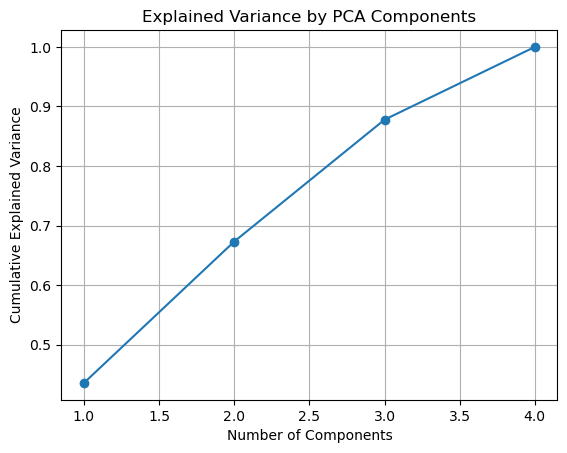


Explained Variance Ratio:
[0.43564725 0.23748057 0.20469388 0.1221783 ]

Explained Variance by PCA Components
[0.43564725 0.67312782 0.8778217  1.        ]


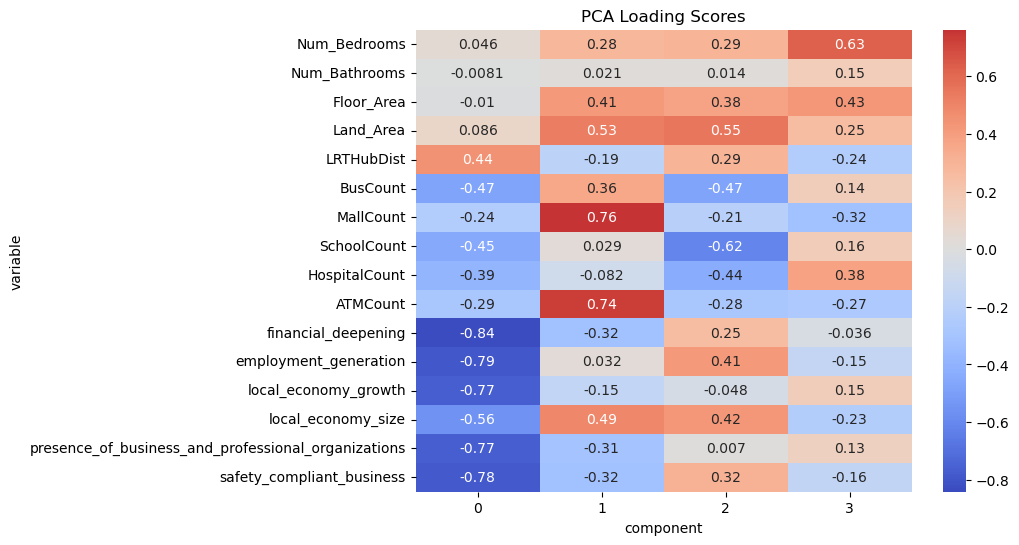

        PC1       PC2       PC3       PC4
0  2.059654 -1.260480  0.046484 -0.478873
1  2.076764 -1.313968  0.020831 -0.535074
2  2.075090 -1.410291 -0.038426 -0.634325
3  2.050780 -1.409507 -0.112246 -0.631752
4  1.754422 -1.063833 -0.360318  0.146045
component                                                  0         1  \
variable                                                                 
Num_Bedrooms                                        0.045997  0.281914   
Num_Bathrooms                                      -0.008147  0.021211   
Floor_Area                                         -0.010074  0.411484   
Land_Area                                           0.085629  0.527582   
LRTHubDist                                          0.443145 -0.189227   
BusCount                                           -0.473426  0.358381   
MallCount                                          -0.235060  0.761498   
SchoolCount                                        -0.450951  0.029440   
Hospital

In [672]:
# Example Usage
X_pca, loading_scores, explained_variance = perform_pca(X_house, n_components=4)

# Display Results
print(X_pca.head())             # Transformed PCA data
print(loading_scores)           # Variable contributions per component
print(explained_variance)       # Explained variance for each component
house_pca = pd.concat([longlat_house[['Latitude', 'Longitude']].reset_index(drop=True), y_house_scaled[['Price']].reset_index(drop=True), 
                        X_pca.reset_index(drop=True)], axis=1)
house_pca.head()
house_pca.to_csv('house_pca.csv', index=False)

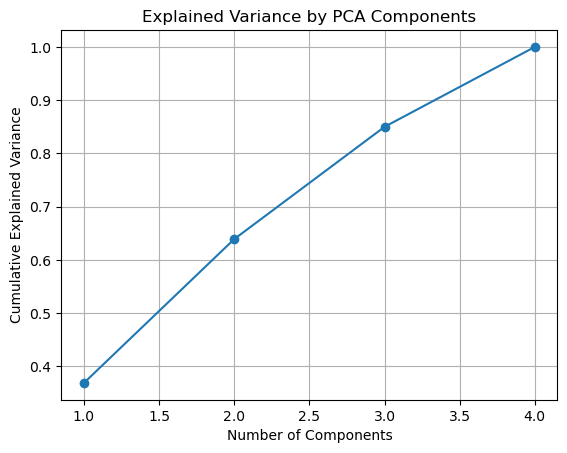


Explained Variance Ratio:
[0.36868092 0.27025912 0.21092598 0.15013399]

Explained Variance by PCA Components
[0.36868092 0.63894003 0.84986601 1.        ]


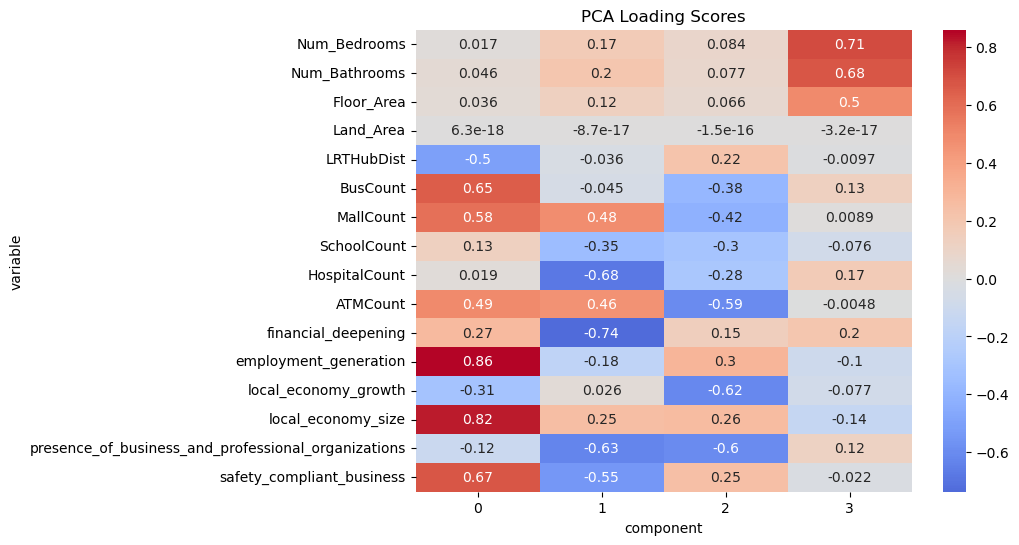

        PC1       PC2       PC3       PC4
0 -0.565303 -1.337856 -0.623476 -0.273609
1 -0.535981 -1.653211 -0.750333  1.299952
2 -0.535981 -1.653211 -0.750333  1.299952
3 -0.563072 -1.832167 -0.838526  0.404528
4 -0.535981 -1.653211 -0.750333  1.299952
component                                                      0  \
variable                                                           
Num_Bedrooms                                        1.739642e-02   
Num_Bathrooms                                       4.633187e-02   
Floor_Area                                          3.615042e-02   
Land_Area                                           6.333631e-18   
LRTHubDist                                         -5.022709e-01   
BusCount                                            6.517728e-01   
MallCount                                           5.846974e-01   
SchoolCount                                         1.346442e-01   
HospitalCount                                       1.913787e-02   


In [673]:
# Example Usage
X_pca, loading_scores, explained_variance = perform_pca(X_condo, n_components=4)

# Display Results
print(X_pca.head())             # Transformed PCA data
print(loading_scores)           # Variable contributions per component
print(explained_variance)       # Explained variance for each component
condo_pca = pd.concat([longlat_condo[['Latitude', 'Longitude']].reset_index(drop=True), y_condo_scaled[['Price']].reset_index(drop=True), 
                        X_pca.reset_index(drop=True)], axis=1)
condo_pca.head()
condo_pca.to_csv('condo_pca.csv', index=False)

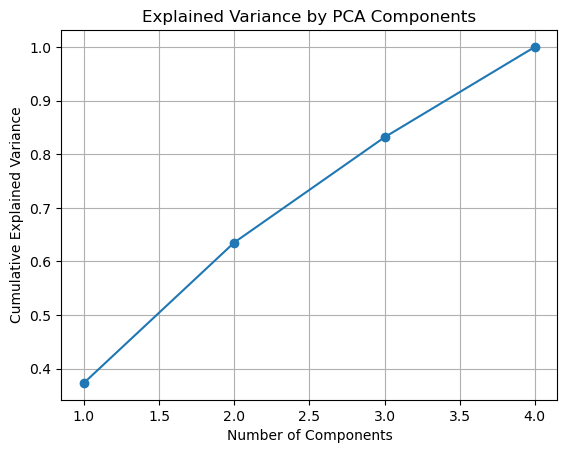


Explained Variance Ratio:
[0.37364729 0.26176576 0.19619427 0.16839267]

Explained Variance by PCA Components
[0.37364729 0.63541305 0.83160733 1.        ]


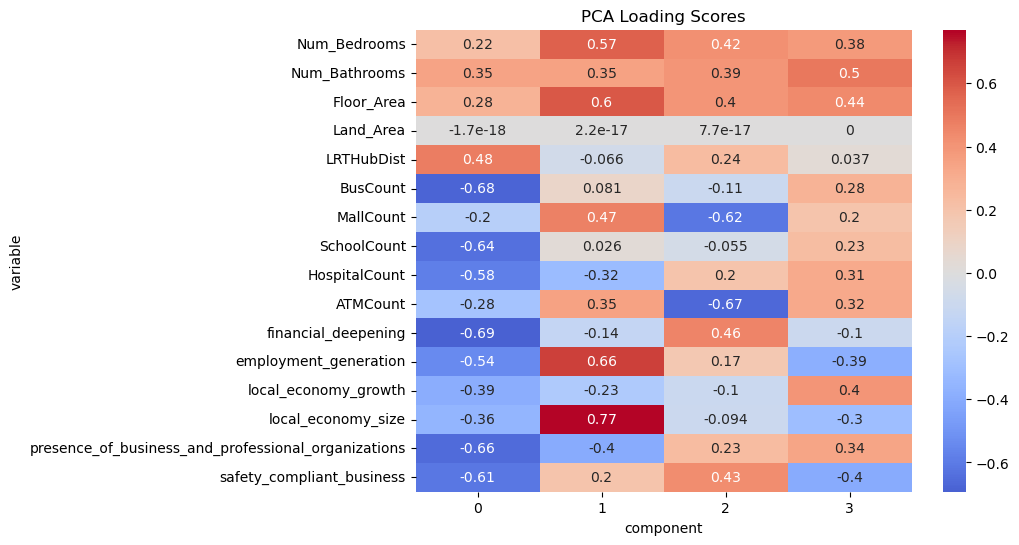

        PC1       PC2       PC3       PC4
0 -0.507916 -1.154585 -0.542337  0.713186
1  0.712626 -0.126531 -0.208336  0.414257
2  0.005552 -1.399244 -0.064091  0.130559
3  0.826355 -1.215638  0.386109 -0.146958
4  1.315840 -1.175794  0.325770 -0.737161
component                                                      0  \
variable                                                           
Num_Bedrooms                                        2.189148e-01   
Num_Bathrooms                                       3.461341e-01   
Floor_Area                                          2.821533e-01   
Land_Area                                          -1.661850e-18   
LRTHubDist                                          4.820664e-01   
BusCount                                           -6.799942e-01   
MallCount                                          -1.954832e-01   
SchoolCount                                        -6.409275e-01   
HospitalCount                                      -5.813490e-01   


In [674]:
# Example Usage
X_pca, loading_scores, explained_variance = perform_pca(X_apt, n_components=4)

# Display Results
print(X_pca.head())             # Transformed PCA data
print(loading_scores)           # Variable contributions per component
print(explained_variance)       # Explained variance for each component
apt_pca = pd.concat([longlat_apt[['Latitude', 'Longitude']].reset_index(drop=True), y_apt_scaled[['Price']].reset_index(drop=True), 
                        X_pca.reset_index(drop=True)], axis=1)
apt_pca.head()
apt_pca.to_csv('apt_pca.csv', index=False)

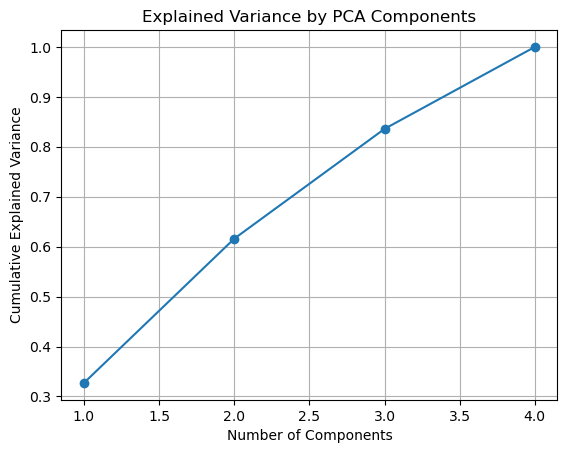


Explained Variance Ratio:
[0.32709807 0.28887633 0.21991017 0.16411544]

Explained Variance by PCA Components
[0.32709807 0.61597439 0.83588456 1.        ]


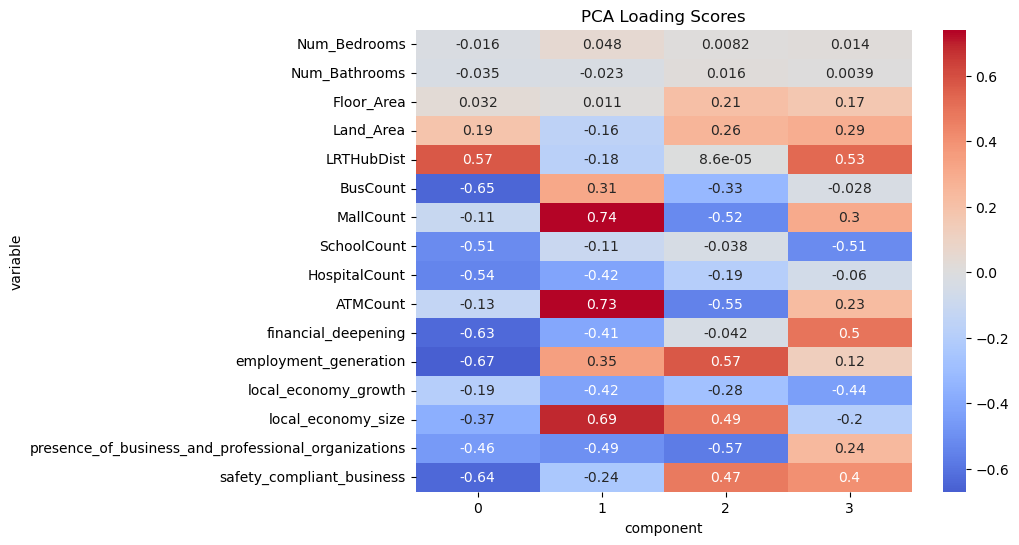

        PC1       PC2       PC3       PC4
0  0.282838 -1.525718 -0.011016 -1.520658
1  2.112183 -1.412379  0.558857 -0.259513
2  0.879788 -1.384205  0.464118 -1.564336
3  0.265154 -1.507776 -0.029885 -1.550190
4 -0.199579 -1.364004 -0.584258 -1.120674
component                                                  0         1  \
variable                                                                 
Num_Bedrooms                                       -0.015539  0.048329   
Num_Bathrooms                                      -0.034744 -0.022609   
Floor_Area                                          0.032059  0.011071   
Land_Area                                           0.188359 -0.157746   
LRTHubDist                                          0.573710 -0.176004   
BusCount                                           -0.648583  0.310209   
MallCount                                          -0.112486  0.739980   
SchoolCount                                        -0.513497 -0.106622   
Hospital

In [676]:
# Example Usage
X_pca, loading_scores, explained_variance = perform_pca(X_com, n_components=4)

# Display Results
print(X_pca.head())             # Transformed PCA data
print(loading_scores)           # Variable contributions per component
print(explained_variance)       # Explained variance for each component
com_pca = pd.concat([longlat_com[['Latitude', 'Longitude']].reset_index(drop=True), y_com_scaled[['Price']].reset_index(drop=True), 
                        X_pca.reset_index(drop=True)], axis=1)
com_pca.head()
com_pca.to_csv('com_pca.csv', index=False)

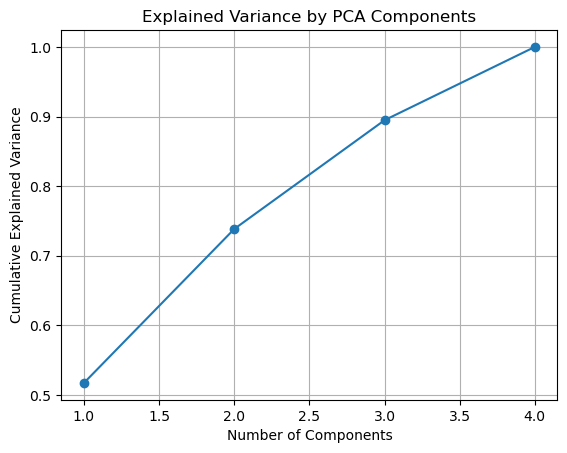


Explained Variance Ratio:
[0.51728379 0.22114081 0.15630577 0.10526963]

Explained Variance by PCA Components
[0.51728379 0.7384246  0.89473037 1.        ]


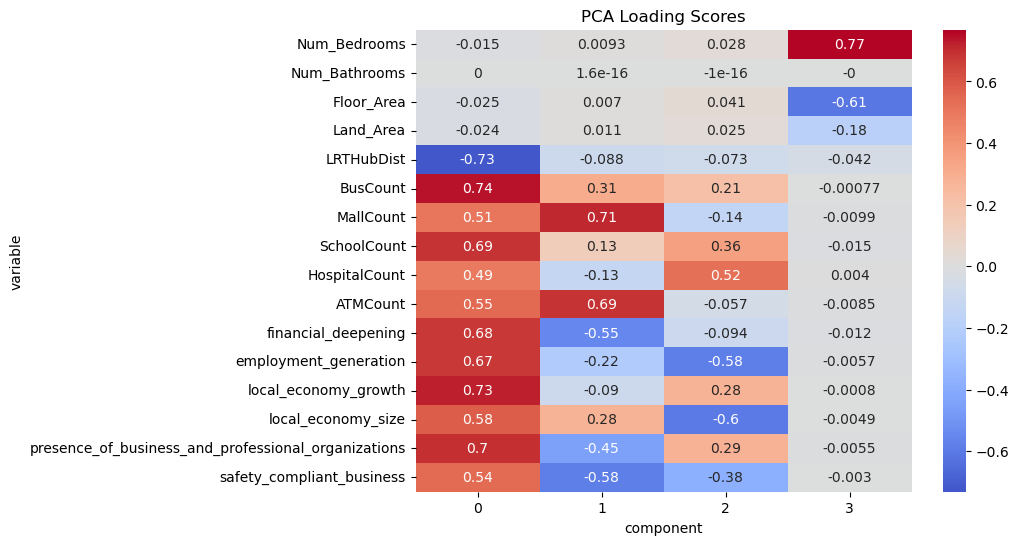

        PC1       PC2       PC3       PC4
0 -1.140629 -0.518486  0.526725  0.045407
1 -0.563196 -0.500907  1.222300  0.065787
2 -0.563208 -0.500898  1.222324  0.065578
3  0.169290 -0.230183  1.689646  0.050799
4  0.169292 -0.230184  1.689642  0.050836
component                                                  0             1  \
variable                                                                     
Num_Bedrooms                                       -0.015057  9.250900e-03   
Num_Bathrooms                                       0.000000  1.610216e-16   
Floor_Area                                         -0.025472  7.003458e-03   
Land_Area                                          -0.024259  1.138120e-02   
LRTHubDist                                         -0.731789 -8.807407e-02   
BusCount                                            0.743470  3.075210e-01   
MallCount                                           0.506935  7.101014e-01   
SchoolCount                                   

In [680]:
# Example Usage
X_pca, loading_scores, explained_variance = perform_pca(X_land, n_components=4)

# Display Results
print(X_pca.head())             # Transformed PCA data
print(loading_scores)           # Variable contributions per component
print(explained_variance)       # Explained variance for each component
land_pca = pd.concat([longlat_land[['Latitude', 'Longitude']].reset_index(drop=True), y_land_scaled[['Price']].reset_index(drop=True), 
                        X_pca.reset_index(drop=True)], axis=1)
land_pca.head()
land_pca.to_csv('land_pca.csv', index=False)

### PCA without LRT and Price

In [683]:
X_house_wo_lrt = house_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening','employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_condo_wo_lrt = condo_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening','employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_apt_wo_lrt = apt_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening','employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_com_wo_lrt = com_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening','employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_land_wo_lrt = land_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening','employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]

In [685]:
y_lrt_house = house_df[['Price', 'LRTHubDist']]
y_lrt_condo = condo_df[['Price', 'LRTHubDist']]
y_lrt_apt = apt_df[['Price', 'LRTHubDist']]
y_lrt_com = com_df[['Price', 'LRTHubDist']]
y_lrt_land = land_df[['Price', 'LRTHubDist']]

In [687]:
# Standardize the Price and LRTHubDist

y_lrt_house_scaled = pd.DataFrame(StandardScaler().fit_transform(y_lrt_house), columns=y_lrt_house.columns)
y_lrt_condo_scaled = pd.DataFrame(StandardScaler().fit_transform(y_lrt_condo), columns=y_lrt_condo.columns)
y_lrt_apt_scaled = pd.DataFrame(StandardScaler().fit_transform(y_lrt_apt), columns=y_lrt_apt.columns)
y_lrt_com_scaled = pd.DataFrame(StandardScaler().fit_transform(y_lrt_com), columns=y_lrt_com.columns)
y_lrt_land_scaled = pd.DataFrame(StandardScaler().fit_transform(y_lrt_land), columns=y_lrt_land.columns)

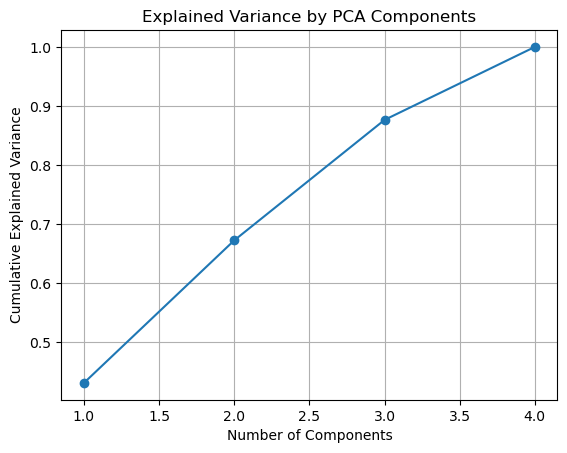


Explained Variance Ratio:
[0.43104958 0.24141697 0.2039723  0.12356115]

Explained Variance by PCA Components
[0.43104958 0.67246655 0.87643885 1.        ]


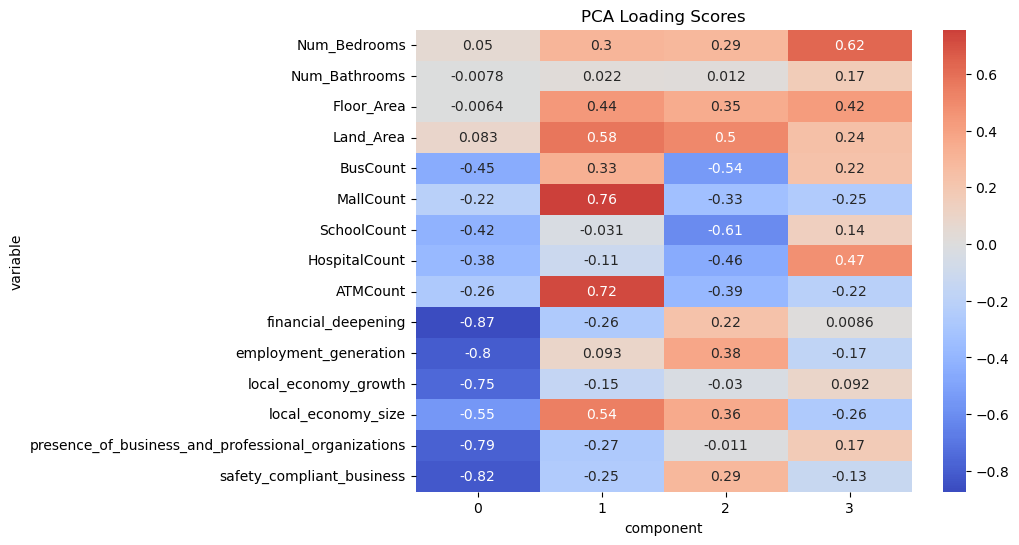

        PC1       PC2       PC3       PC4
0  1.923194 -1.259501  0.165739 -0.475626
1  1.920154 -1.305200  0.123712 -0.510499
2  1.973804 -1.435372  0.132045 -0.663435
3  1.914060 -1.421996  0.017720 -0.627312
4  1.719966 -1.145041 -0.163334  0.047644
component                                                  0         1  \
variable                                                                 
Num_Bedrooms                                        0.050027  0.302152   
Num_Bathrooms                                      -0.007776  0.022411   
Floor_Area                                         -0.006383  0.442861   
Land_Area                                           0.082830  0.576357   
BusCount                                           -0.448341  0.325714   
MallCount                                          -0.217684  0.755424   
SchoolCount                                        -0.415252 -0.030736   
HospitalCount                                      -0.378071 -0.111823   
ATMCount

In [691]:
# Example Usage
X_pca, loading_scores, explained_variance = perform_pca(X_house_wo_lrt, n_components=4)

# Display Results
print(X_pca.head())             # Transformed PCA data
print(loading_scores)           # Variable contributions per component
print(explained_variance)       # Explained variance for each component
lrt_house_pca = pd.concat([longlat_house[['Latitude', 'Longitude']].reset_index(drop=True), y_lrt_house_scaled[['Price', 'LRTHubDist']].reset_index(drop=True), 
                        X_pca.reset_index(drop=True)], axis=1)
lrt_house_pca.head()
lrt_house_pca.to_csv('lrt_house_pca.csv', index=False)

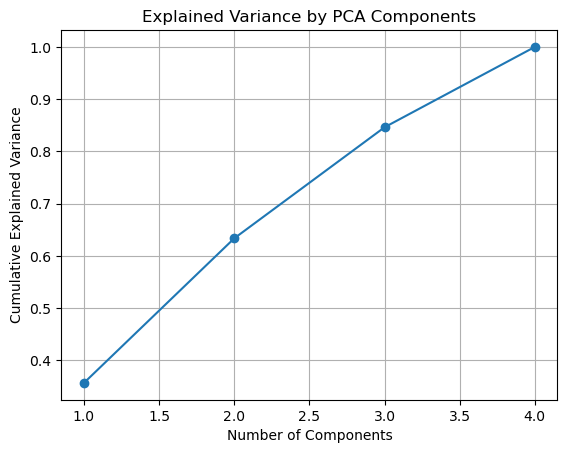


Explained Variance Ratio:
[0.3567172  0.27680692 0.21264545 0.15383043]

Explained Variance by PCA Components
[0.3567172  0.63352412 0.84616957 1.        ]


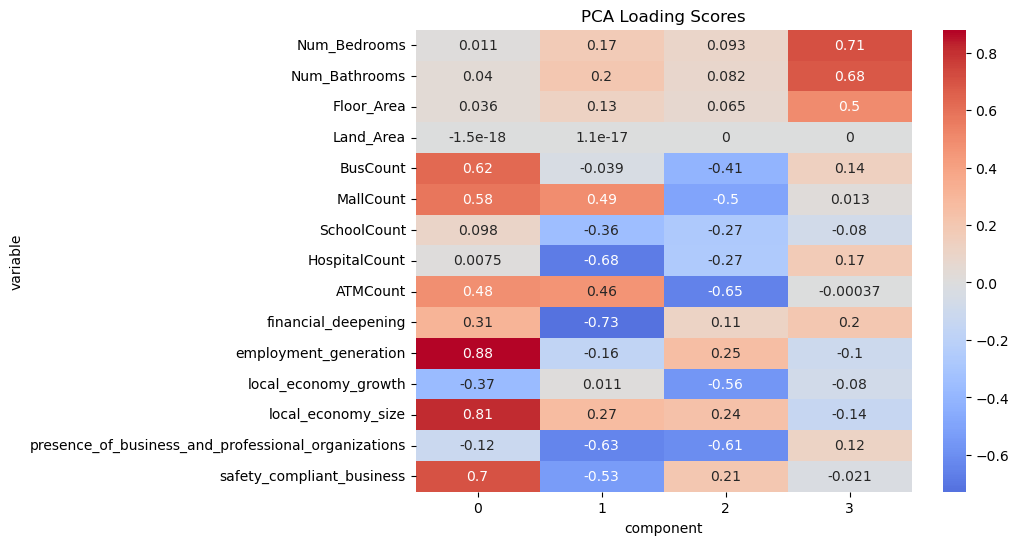

        PC1       PC2       PC3       PC4
0 -0.874931 -1.383347 -0.363377 -0.285975
1 -0.866174 -1.702176 -0.458302  1.284473
2 -0.866174 -1.702176 -0.458302  1.284473
3 -0.888865 -1.881547 -0.554439  0.390645
4 -0.866174 -1.702176 -0.458302  1.284473
component                                                      0  \
variable                                                           
Num_Bedrooms                                        1.077283e-02   
Num_Bathrooms                                       3.987770e-02   
Floor_Area                                          3.590181e-02   
Land_Area                                          -1.538663e-18   
BusCount                                            6.224095e-01   
MallCount                                           5.834644e-01   
SchoolCount                                         9.847339e-02   
HospitalCount                                       7.458043e-03   
ATMCount                                            4.777860e-01   


In [692]:
# Example Usage
X_pca, loading_scores, explained_variance = perform_pca(X_condo_wo_lrt, n_components=4)

# Display Results
print(X_pca.head())             # Transformed PCA data
print(loading_scores)           # Variable contributions per component
print(explained_variance)       # Explained variance for each component
lrt_condo_pca = pd.concat([longlat_condo[['Latitude', 'Longitude']].reset_index(drop=True), y_lrt_condo_scaled[['Price', 'LRTHubDist']].reset_index(drop=True), 
                        X_pca.reset_index(drop=True)], axis=1)
lrt_condo_pca.head()
lrt_condo_pca.to_csv('lrt_condo_pca.csv', index=False)

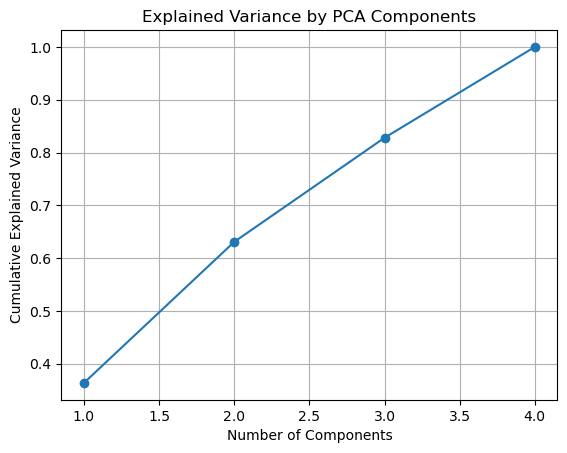


Explained Variance Ratio:
[0.36360682 0.26717693 0.19719149 0.17202476]

Explained Variance by PCA Components
[0.36360682 0.63078375 0.82797524 1.        ]


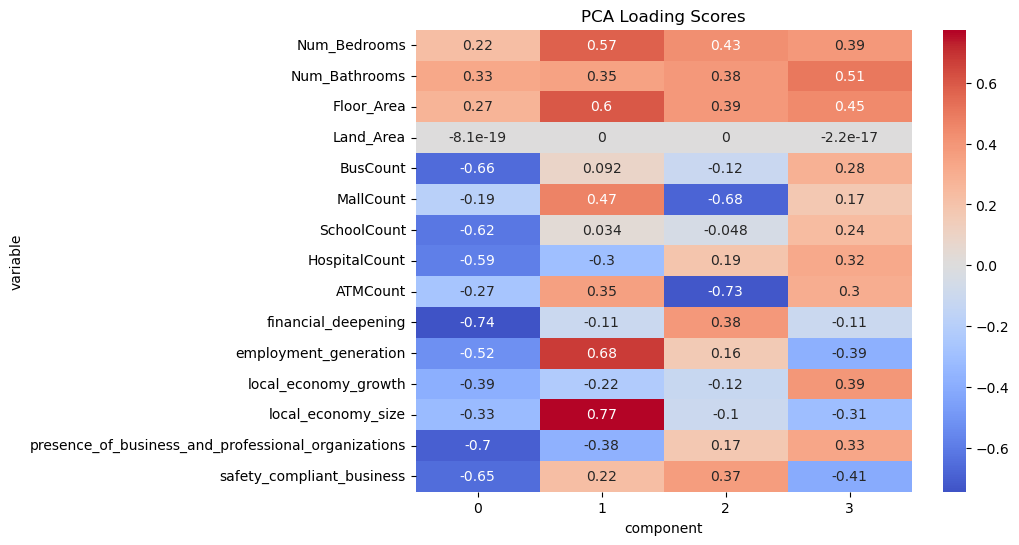

        PC1       PC2       PC3       PC4
0 -0.330183 -1.184138 -0.412151  0.731112
1  0.865702 -0.172353 -0.082800  0.431209
2  0.213032 -1.445805  0.165400  0.173986
3  0.897736 -1.251679  0.549469 -0.112144
4  1.416760 -1.228508  0.523526 -0.702382
component                                                      0         1  \
variable                                                                     
Num_Bedrooms                                        2.229512e-01  0.574365   
Num_Bathrooms                                       3.269589e-01  0.351420   
Floor_Area                                          2.748922e-01  0.596252   
Land_Area                                          -8.108259e-19  0.000000   
BusCount                                           -6.587050e-01  0.091764   
MallCount                                          -1.874477e-01  0.469479   
SchoolCount                                        -6.167698e-01  0.034498   
HospitalCount                                 

In [695]:
# Example Usage
X_pca, loading_scores, explained_variance = perform_pca(X_apt_wo_lrt, n_components=4)

# Display Results
print(X_pca.head())             # Transformed PCA data
print(loading_scores)           # Variable contributions per component
print(explained_variance)       # Explained variance for each component
lrt_apt_pca = pd.concat([longlat_apt[['Latitude', 'Longitude']].reset_index(drop=True), y_lrt_apt_scaled[['Price', 'LRTHubDist']].reset_index(drop=True), 
                        X_pca.reset_index(drop=True)], axis=1)
lrt_apt_pca.head()
lrt_apt_pca.to_csv('lrt_apt_pca.csv', index=False)

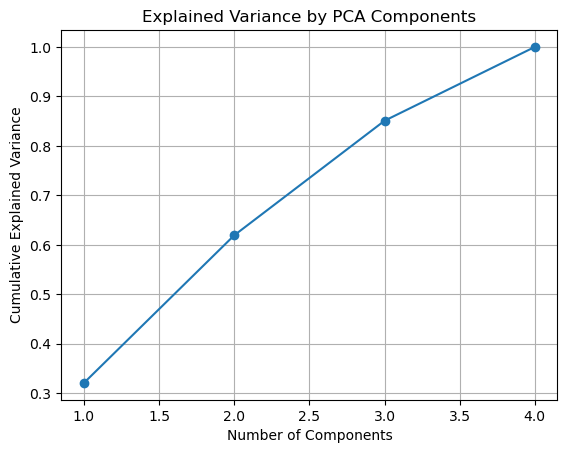


Explained Variance Ratio:
[0.32079042 0.29842303 0.23156739 0.14921916]

Explained Variance by PCA Components
[0.32079042 0.61921345 0.85078084 1.        ]


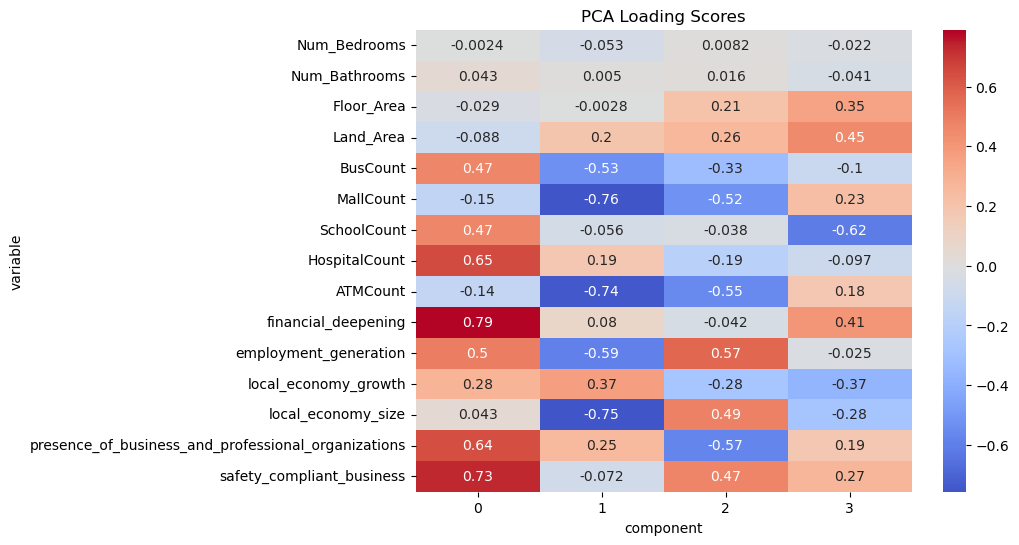

        PC1       PC2       PC3       PC4
0 -0.043226  1.851746 -0.010843 -0.935087
1 -1.266502  2.014267  0.558944 -0.270360
2 -0.610861  1.922001  0.464305 -0.995155
3 -0.035424  1.829955 -0.029711 -0.977175
4  0.397178  1.461149 -0.584131 -0.585766
component                                                  0         1  \
variable                                                                 
Num_Bedrooms                                       -0.002441 -0.052536   
Num_Bathrooms                                       0.043269  0.005019   
Floor_Area                                         -0.029173 -0.002757   
Land_Area                                          -0.088350  0.195300   
BusCount                                            0.465327 -0.527269   
MallCount                                          -0.151413 -0.756855   
SchoolCount                                         0.468099 -0.056013   
HospitalCount                                       0.646446  0.185472   
ATMCount

In [697]:
# Example Usage
X_pca, loading_scores, explained_variance = perform_pca(X_com_wo_lrt, n_components=4)

# Display Results
print(X_pca.head())             # Transformed PCA data
print(loading_scores)           # Variable contributions per component
print(explained_variance)       # Explained variance for each component
lrt_com_pca = pd.concat([longlat_com[['Latitude', 'Longitude']].reset_index(drop=True), y_lrt_com_scaled[['Price', 'LRTHubDist']].reset_index(drop=True), 
                        X_pca.reset_index(drop=True)], axis=1)
lrt_com_pca.head()
lrt_com_pca.to_csv('lrt_com_pca.csv', index=False)

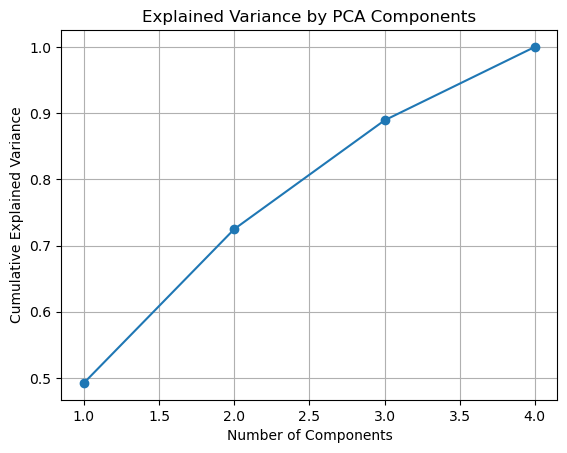


Explained Variance Ratio:
[0.49242529 0.23234579 0.16433995 0.11088896]

Explained Variance by PCA Components
[0.49242529 0.72477109 0.88911104 1.        ]


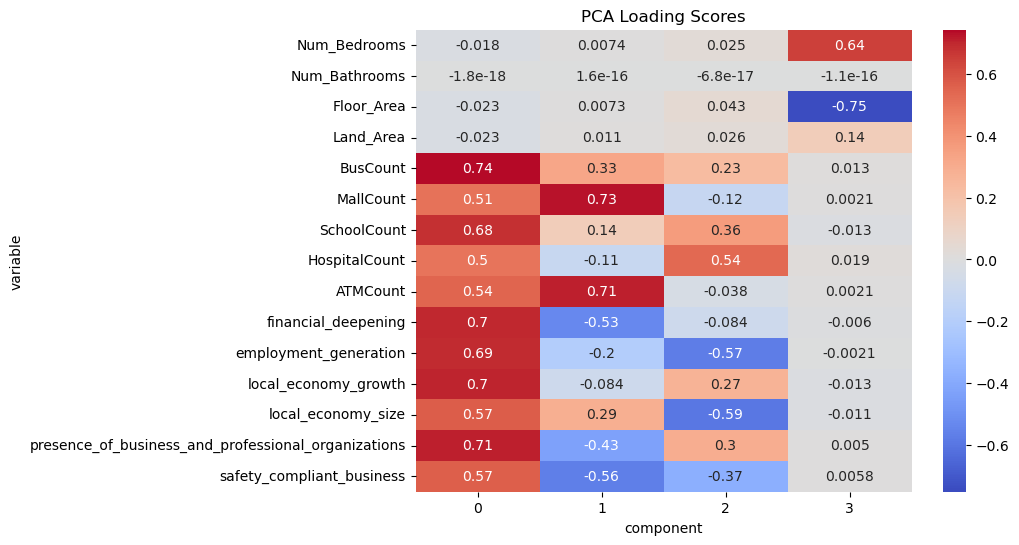

        PC1       PC2       PC3       PC4
0 -1.270659 -0.582799  0.468613  0.002263
1 -0.786264 -0.570966  1.164277  0.033995
2 -0.786277 -0.570957  1.164301  0.034155
3 -0.188952 -0.315810  1.612621 -0.004954
4 -0.188949 -0.315811  1.612616 -0.004982
component                                                      0  \
variable                                                           
Num_Bedrooms                                       -1.844707e-02   
Num_Bathrooms                                      -1.828371e-18   
Floor_Area                                         -2.330104e-02   
Land_Area                                          -2.326593e-02   
BusCount                                            7.426898e-01   
MallCount                                           5.087256e-01   
SchoolCount                                         6.793999e-01   
HospitalCount                                       5.023142e-01   
ATMCount                                            5.447521e-01   


In [699]:
# Example Usage
X_pca, loading_scores, explained_variance = perform_pca(X_land_wo_lrt, n_components=4)

# Display Results
print(X_pca.head())             # Transformed PCA data
print(loading_scores)           # Variable contributions per component
print(explained_variance)       # Explained variance for each component
lrt_land_pca = pd.concat([longlat_land[['Latitude', 'Longitude']].reset_index(drop=True), y_lrt_land_scaled[['Price', 'LRTHubDist']].reset_index(drop=True), 
                        X_pca.reset_index(drop=True)], axis=1)
lrt_land_pca.head()
lrt_land_pca.to_csv('lrt_land_pca.csv', index=False)

### Regression on PCA datasets

In [455]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [471]:
def linear_model_lrt(df):
    y = df['Price']
    X = df[['LRTHubDist','PC1','PC2', 'PC3','PC4']]
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
    
    r2_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
    mse_scores = -cross_val_score(pipeline, X, y, cv=5, scoring='neg_mean_squared_error')
    
    print("\n===== Cross-Validation Linear Regression Results =====")
    print(f"Average R²: {np.mean(r2_scores):.4f}")
    print(f"Average MSE: {np.mean(mse_scores):.4f}")
    
    pipeline.fit(X, y)
    coefs = pipeline.named_steps['model'].coef_
    
    results_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": coefs.round(4)
    })
    
    print("\nCoefficients:\n", results_df.to_string(index=False))
    
    return results_df

In [473]:
linear_model_lrt(lrt_house_pca)


===== Cross-Validation Linear Regression Results =====
Average R²: -2.0981
Average MSE: 0.8776

Coefficients:
    Feature  Coefficient
LRTHubDist      -0.0698
       PC1       0.0018
       PC2       0.3740
       PC3       0.2762
       PC4       0.0439


,Feature,Coefficient
0,LRTHubDist,-0.0698
1,PC1,0.0018
2,PC2,0.3740
3,PC3,0.2762
4,PC4,0.0439


In [475]:
linear_model_lrt(lrt_condo_pca)


===== Cross-Validation Linear Regression Results =====
Average R²: 0.0624
Average MSE: 0.9607

Coefficients:
    Feature  Coefficient
LRTHubDist      -0.0181
       PC1       0.0312
       PC2       0.1114
       PC3       0.0518
       PC4       0.1795


,Feature,Coefficient
0,LRTHubDist,-0.0181
1,PC1,0.0312
2,PC2,0.1114
3,PC3,0.0518
4,PC4,0.1795


In [477]:
linear_model_lrt(lrt_apt_pca)


===== Cross-Validation Linear Regression Results =====
Average R²: 0.1390
Average MSE: 0.6961

Coefficients:
    Feature  Coefficient
LRTHubDist      -0.0075
       PC1       0.1836
       PC2       0.5566
       PC3       0.2373
       PC4       0.3085


,Feature,Coefficient
0,LRTHubDist,-0.0075
1,PC1,0.1836
2,PC2,0.5566
3,PC3,0.2373
4,PC4,0.3085


In [479]:
linear_model_lrt(lrt_com_pca)


===== Cross-Validation Linear Regression Results =====
Average R²: 0.0273
Average MSE: 0.9630

Coefficients:
    Feature  Coefficient
LRTHubDist      -0.1466
       PC1      -0.0802
       PC2      -0.0020
       PC3       0.1485
       PC4       0.2531


,Feature,Coefficient
0,LRTHubDist,-0.1466
1,PC1,-0.0802
2,PC2,-0.0020
3,PC3,0.1485
4,PC4,0.2531


In [481]:
linear_model_lrt(lrt_land_pca)


===== Cross-Validation Linear Regression Results =====
Average R²: -5.6533
Average MSE: 1.0224

Coefficients:
    Feature  Coefficient
LRTHubDist      -0.0125
       PC1      -0.0054
       PC2       0.0225
       PC3       0.0057
       PC4       0.0295


,Feature,Coefficient
0,LRTHubDist,-0.0125
1,PC1,-0.0054
2,PC2,0.0225
3,PC3,0.0057
4,PC4,0.0295


In [483]:
def linear_model(df):
    y = df['Price']
    X = df[['PC1','PC2', 'PC3','PC4']]
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
    
    r2_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
    mse_scores = -cross_val_score(pipeline, X, y, cv=5, scoring='neg_mean_squared_error')
    
    print("\n===== Cross-Validation Linear Regression Results =====")
    print(f"Average R²: {np.mean(r2_scores):.4f}")
    print(f"Average MSE: {np.mean(mse_scores):.4f}")
    
    pipeline.fit(X, y)
    coefs = pipeline.named_steps['model'].coef_
    
    results_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": coefs.round(4)
    })
    
    print("\nCoefficients:\n", results_df.to_string(index=False))
    
    return results_df

In [485]:
linear_model(house_pca)


===== Cross-Validation Linear Regression Results =====
Average R²: -1.8306
Average MSE: 0.8733

Coefficients:
 Feature  Coefficient
    PC1      -0.0289
    PC2       0.3583
    PC3       0.2900
    PC4       0.0661


,Feature,Coefficient
0,PC1,-0.0289
1,PC2,0.3583
2,PC3,0.2900
3,PC4,0.0661


In [487]:
linear_model(condo_pca)


===== Cross-Validation Linear Regression Results =====
Average R²: 0.0603
Average MSE: 0.9607

Coefficients:
 Feature  Coefficient
    PC1       0.0393
    PC2       0.1110
    PC3       0.0504
    PC4       0.1797


,Feature,Coefficient
0,PC1,0.0393
1,PC2,0.1110
2,PC3,0.0504
3,PC4,0.1797


In [489]:
linear_model(apt_pca)


===== Cross-Validation Linear Regression Results =====
Average R²: 0.1835
Average MSE: 0.6760

Coefficients:
 Feature  Coefficient
    PC1       0.1769
    PC2       0.5577
    PC3       0.2399
    PC4       0.3036


,Feature,Coefficient
0,PC1,0.1769
1,PC2,0.5577
2,PC3,0.2399
3,PC4,0.3036


In [491]:
linear_model(com_pca)


===== Cross-Validation Linear Regression Results =====
Average R²: 0.0198
Average MSE: 0.9851

Coefficients:
 Feature  Coefficient
    PC1       0.0105
    PC2       0.0509
    PC3       0.1484
    PC4       0.0790


,Feature,Coefficient
0,PC1,0.0105
1,PC2,0.0509
2,PC3,0.1484
3,PC4,0.0790


In [493]:
linear_model(land_pca)


===== Cross-Validation Linear Regression Results =====
Average R²: -16.8747
Average MSE: 1.0646

Coefficients:
 Feature  Coefficient
    PC1       0.0044
    PC2       0.0237
    PC3       0.0064
    PC4      -0.0412


,Feature,Coefficient
0,PC1,0.0044
1,PC2,0.0237
2,PC3,0.0064
3,PC4,-0.0412
